In [1]:
from models.diffusion import Denoiser, DenoiserConfig, SigmaDistributionConfig
from models.actor_critic import ActorCritic, ActorCriticConfig, ActorCriticLossConfig
from omegaconf import DictConfig, OmegaConf
import yaml

# Model

In [13]:
with open("/home/monsh/works/image/madx/madx/config/trainer.yaml", "r") as f:
    cfg = yaml.safe_load(f)
    # config = config['denoiser']

    # For boxing
    cfg['agent']['denoiser']['inner_model']['num_actions'] = 18
    cfg['agent']['actor_critic']['num_actions'] = 18

cfg = OmegaConf.structured(cfg)

In [3]:
denoiser = Denoiser(cfg.agent.denoiser).to("cuda:0")
actor_critic = ActorCritic(cfg.agent.actor_critic).to("cuda:0")

# Training

In [11]:
import torch
from utils import (get_lr_sched, configure_opt, broadcast_if_needed, keep_agent_copies_every)

def build_opt(model, cfg) -> torch.optim.AdamW:
    return configure_opt(model, **cfg.optimizer)

def build_lr_sched(opt, cfg) -> torch.optim.lr_scheduler.LambdaLR:
    return get_lr_sched(opt, num_warmup_steps=cfg.training.lr_warmup_steps)

In [5]:
from functools import partial
from torch.utils.data import DataLoader
from data import BatchSampler, collate_segments_to_batch, Dataset, DatasetTraverser
import torch.distributed as dist
from pathlib import Path
from envs import make_atari_env, WorldModelEnv
from coroutines.collector import make_collector, NumToCollect

_use_cuda = True
_device = torch.device("cuda" if _use_cuda else "cpu")
_rank = dist.get_rank() if dist.is_initialized() else 0
_world_size = dist.get_world_size() if dist.is_initialized() else 1
_is_static_dataset = cfg.static_dataset.path is not None
_is_model_free = True

num_workers = cfg.training.num_workers_data_loaders
use_manager = cfg.training.cache_in_ram and (num_workers > 0)
train_dataset = Dataset(Path("dataset") / "train", "train_dataset", cfg.training.cache_in_ram, use_manager)
train_dataset._default_path = Path("/home/monsh/works/image/madx/madx/dataset/train/info.pt")
train_dataset.load_from_default_path()

# Envs
if _rank == 0:
    train_env = make_atari_env(num_envs=cfg.collection.train.num_envs, device=_device, **cfg.env.train)
    # test_env = make_atari_env(num_envs=cfg.collection.test.num_envs, device=self._device, **cfg.env.test)
    num_actions = int(train_env.num_actions)
else:
    num_actions = None

(num_actions,) = broadcast_if_needed(num_actions)

# Collectors
if not _is_static_dataset and _rank == 0:
    _train_collector = make_collector(train_env, actor_critic, train_dataset, cfg.collection.train.epsilon)

if _is_model_free:
    rl_env = make_atari_env(num_envs=cfg.actor_critic.training.batch_size, device=_device, **cfg.env.train)

denoiser.setup_training(OmegaConf.structured(cfg.agent.denoiser.sigma_distribution))
actor_critic.setup_training(rl_env, cfg.actor_critic.actor_critic_loss)

make_data_loader = partial(
    DataLoader,
    dataset=train_dataset,
    collate_fn=collate_segments_to_batch,
    num_workers=num_workers,
    persistent_workers=(num_workers > 0),
    pin_memory=_use_cuda,
    pin_memory_device="cuda",
)

make_batch_sampler = partial(BatchSampler, train_dataset, _rank, _world_size)


def get_sample_weights(sample_weights):
    return None if (_is_static_dataset and cfg.static_dataset.ignore_sample_weights) else sample_weights

c = cfg.training
seq_length = cfg.agent.denoiser.inner_model.num_steps_conditioning + 1 + c.num_autoregressive_steps
bs = make_batch_sampler(c.batch_size, seq_length, get_sample_weights(c.sample_weights))
dl_denoiser_train = make_data_loader(batch_sampler=bs)


/home/monsh/works/image/madx/madx/data/dataset.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self._default_path))
A.L.E: Arcade Learn

In [6]:
num_epochs_collect = 0
num_epochs = 0 + cfg.training.num_final_epochs
num_batch_train = 0


In [7]:
from tqdm import tqdm, trange

def train_agent(model, cfg, epoch, data_loader, num_batch_train, opt, lr_sched):
    model.train()
    model.zero_grad()
    
    to_log = []
    
    if epoch > cfg.training.start_after_epochs:
        steps = cfg.training.steps_first_epoch if epoch == 1 else cfg.training.steps_per_epoch
        to_log += train_component(denoiser, cfg, steps, data_loader, num_batch_train, opt, lr_sched)
    return to_log

def train_component(model, cfg, steps, data_loader, num_batch_train, opt, lr_sched):
    _device = torch.device("cuda" if _use_cuda else "cpu")

    model.train()
    opt.zero_grad()
    data_iterator = iter(data_loader) #if data_loader is not None else None
    to_log = []

    num_steps = cfg.training.grad_acc_steps * steps

    for i in trange(num_steps, desc=f"Training", disable=_rank > 0):
        batch = next(data_iterator).to(_device) if data_iterator is not None else None
        loss, metrics = model(batch) if batch is not None else model()
        loss.backward()

        num_batch = num_batch_train
        num_batch_train = num_batch + 1

        if (i + 1) % cfg.training.grad_acc_steps == 0:
            if cfg.training.max_grad_norm is not None:
                grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.training.max_grad_norm)
                metrics["grad_norm_before_clip"] = grad_norm

            opt.step()
            opt.zero_grad()

            if lr_sched is not None:
                metrics["lr"] = lr_sched.get_last_lr()[0]
                lr_sched.step()

        to_log.append(metrics)

    to_log = [{f"denoiser/train/{k}": v for k, v in d.items()} for d in to_log]
    return to_log

    # process_confusion_matrices_if_any_and_compute_classification_metrics(to_log)


In [8]:
epoch = 0
opt = build_opt(denoiser, cfg)
lr_sched = build_lr_sched(opt, cfg)
data_loader = dl_denoiser_train
should_collect_train = True

to_log = []

while epoch < num_epochs:
    epoch += 1
    print(f"\nEpoch {epoch} / {num_epochs}\n")

    if should_collect_train:
        c = cfg.collection.train
        to_log += _train_collector.send(NumToCollect(steps=c.steps_per_epoch))

    (sd_train_dataset,) = broadcast_if_needed(train_dataset.state_dict())  # update dataset for ranks > 0
    train_dataset.load_state_dict(sd_train_dataset)  # Load dataset from episodes and steps

    if cfg.training.should:
        to_log += train_agent(denoiser, cfg, epoch, data_loader, num_batch_train, opt, lr_sched)


Epoch 1 / 50



Training:   0%|          | 0/10000 [00:00<?, ?it/s]/home/monsh/works/image/madx/madx/data/episode.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  for k, v in torch.load


Epoch 2 / 50



Training:  14%|█▍        | 55/400 [00:11<01:09,  4.95it/s]


KeyboardInterrupt: 

In [10]:
denoiser

Denoiser(
  (inner_model): InnerModel(
    (noise_emb): FourierFeatures()
    (act_emb): Sequential(
      (0): Embedding(18, 64)
      (1): Flatten(start_dim=1, end_dim=-1)
    )
    (cond_proj): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
    )
    (conv_in): Conv2d(15, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (unet): UNet(
      (d_blocks): ModuleList(
        (0-3): 4 x ResBlocks(
          (resblocks): ModuleList(
            (0-1): 2 x ResBlock(
              (proj): Identity()
              (norm1): AdaGroupNorm(
                (linear): Linear(in_features=256, out_features=128, bias=True)
              )
              (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (norm2): AdaGroupNorm(
                (linear): Linear(in_features=256, out_features=128, bias=True)
              )
              (conv2): Con

In [14]:
_path_ckpt_dir = Path("checkpoints")

_keep_agent_copies = partial(
    keep_agent_copies_every,
    every=cfg.checkpointing.save_agent_every,
    path_ckpt_dir=_path_ckpt_dir,
    num_to_keep=cfg.checkpointing.num_to_keep,
)


In [18]:
_path_ckpt_dir

PosixPath('checkpoints')

In [20]:
torch.save(
    denoiser.state_dict(),
    _path_ckpt_dir / f"denoiser_{epoch:04d}.pt",
)

# Play

In [159]:
from models.diffusion import Denoiser, DiffusionSampler, DiffusionSamplerConfig


sampler = DiffusionSampler(
    denoiser=denoiser,
    cfg=DiffusionSamplerConfig(
        num_steps_denoising=5
    ),
),

In [31]:
import gymnasium
from envs.atari_preprocessing import AtariPreprocessing

env = gymnasium.make(
    "ALE/Boxing",
    full_action_space=False,
    frameskip=1,
    render_mode="rgb_array",
    max_episode_steps=None,
)

env = AtariPreprocessing(
    env=env,
    noop_max=30,
    frame_skip=4,
    screen_size=64,
)

/home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/gymnasium/envs/registration.py:521: UserWarning: WARN: Using the latest versioned environment `ALE/Boxing-v5` instead of the unversioned environment `ALE/Boxing`.
  logger.warn(


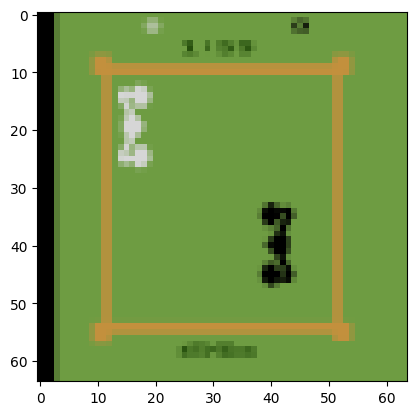

In [160]:
import matplotlib.pyplot as plt

obs, info = env.reset()
plt.imshow(obs)
plt.show()

In [161]:
def show_tensor(tensor):
    tensor = tensor.cpu().numpy()
    tensor = tensor.transpose(1, 2, 0)

    return tensor

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7254902..0.87450993].


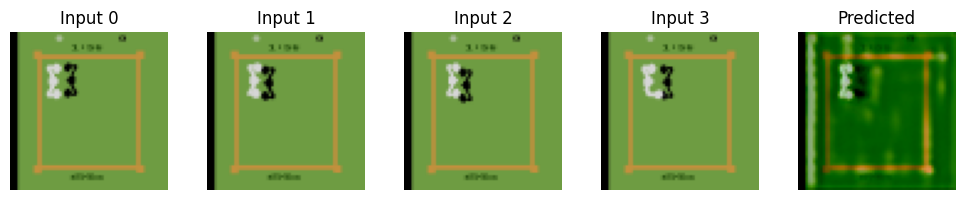

In [169]:
import random
seq = 4

frames = []
actions = []

random_start = random.randint(0, 500)

obs, info = env.reset()

for i in range(1000):
    if len(actions) == seq:
        break

    if i < random_start:
        action = 0
    else:
        action = env.action_space.sample()

    
    obs, reward, terminated, truncated, info = env.step(action)
    if i < random_start:
        continue

    actions.append(action)
    frames.append(obs)

    if terminated or truncated:
        obs, info = env.reset()

# Convert frames from numpy array to tensor

import torch
from torchvision import transforms

transform = transforms.ToTensor()
frames_tensor = [transform(frame) for frame in frames]
frames_tensor = torch.stack(frames_tensor).to("cuda:0")

# Convert actions to tensor
actions_tensor = torch.tensor(actions, dtype=torch.long).to("cuda:0")
x = frames_tensor.unsqueeze(0)
act = actions_tensor.unsqueeze(0)
out = sampler[0].sample(x, act)



n_cols = seq + 1
n_rows = 1

fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

for i in range(n_cols):
    if n_rows == 1:
        ax = axs[i]
    else:
        ax = axs[i // n_cols, i % n_cols]

    if i < seq:
        ax.set_title("Input " + str(i))
        ax.imshow(frames[i])
    else:
        ax.set_title(f"Predicted")
        ax.imshow(show_tensor(out[0][0]))
    
    ax.axis("off")
plt.tight_layout()